In [20]:
import numpy as np
import pandas as pd

import scipy.stats as sts

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

# 9.0

In [21]:
p = np.array([9/16, 3/16, 3/16, 1/16])
n = 556
N_ = np.array([301, 121, 102, 32])

N_exp = n*p
N_exp

sts.chisquare(N_, N_exp, ddof=0)

Power_divergenceResult(statistic=np.float64(3.398880895283773), pvalue=np.float64(0.33411566902575995))

# 9.1

In [22]:
x = np.array([
    -1.28, -1.22, -0.45, -0.35, 0.72,
    -0.32, -0.80, -1.66, 1.39, 0.38,
    -1.38, -1.26, 0.49, -0.14, -0.85,
    2.33, -0.34, -1.96, -0.64, -1.32,
    -1.14, 0.64, 3.44, -1.67, 0.85,
    0.41, -0.01, 0.67, -1.13, -0.41,
    -0.49, 0.36, -1.24, -0.04, -0.11,
    1.05, 0.04, 0.76, 0.61, -2.04,
    0.35, 2.82, -0.46, -0.63, -1.61,
    0.64, 0.56, -0.11, 0.13, -1.81
])

n = len(x)

print("Sample size =", n)
print("Sample mean =", np.mean(x))
print("Sample std =", np.std(x, ddof=1))

Sample size = 50
Sample mean = -0.16459999999999997
Sample std = 1.167229774696814


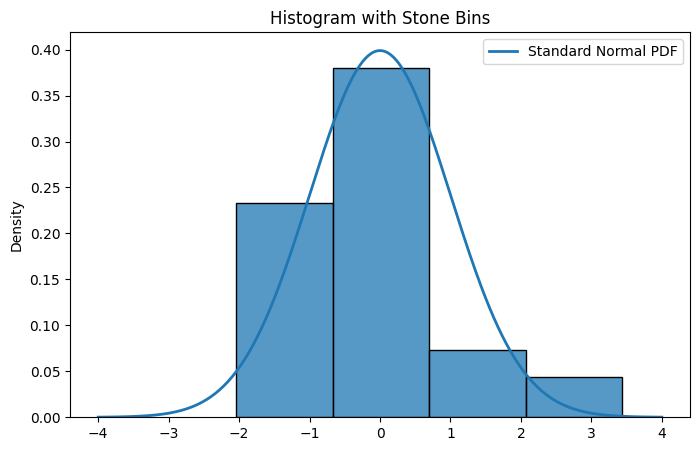

In [23]:
#Histogram with Stone bins

plt.figure(figsize=(8,5))

sns.histplot(
    x,
    bins='stone',
    stat='density',
    kde=False
)

xx = np.linspace(-4, 4, 400)

plt.plot(
    xx,
    sts.norm.pdf(xx),
    linewidth=2,
    label='Standard Normal PDF'
)

plt.title("Histogram with Stone Bins")
plt.legend()
plt.show()

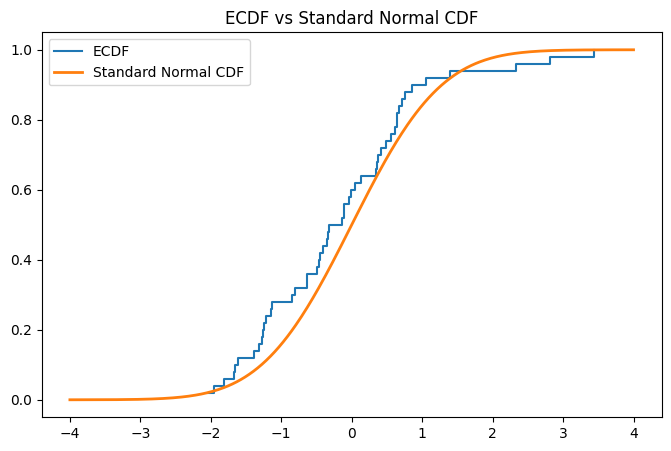

In [24]:
#ECDF vs standard normal CDF

x_sorted = np.sort(x)
ecdf = np.arange(1, n+1) / n

plt.figure(figsize=(8,5))

plt.step(
    x_sorted,
    ecdf,
    where='post',
    label='ECDF'
)

plt.plot(
    xx,
    sts.norm.cdf(xx),
    linewidth=2,
    label='Standard Normal CDF'
)

plt.title("ECDF vs Standard Normal CDF")
plt.legend()
plt.show()

## 2. Interpretation from plot
- The histogram is approximately bell-shaped and centered around 0, similar to a normal distribution.
- The ECDF follows the standard normal CDF fairly closely, with only small deviations in the tails.
- Overall, the sample appears reasonably consistent with a standard normal distribution, so initially there is no strong evidence against normality.

In [25]:
# 3) Chi-square test with 5 equal-probability bins

q5 = sts.norm.ppf([0, 0.2, 0.4, 0.6, 0.8, 1])

obs5, _ = np.histogram(x, bins=q5)

expected5 = np.repeat(n * 0.2, 5)

chi2_5, p5 = sts.chisquare(obs5, expected5)

print("\n--- Chi-square test (5 bins) ---")
print("Observed counts =", obs5)
print("Expected counts =", expected5)
print("Chi-square statistic =", chi2_5)
print("p-value =", p5)


--- Chi-square test (5 bins) ---
Observed counts = [15 10  7 12  6]
Expected counts = [10. 10. 10. 10. 10.]
Chi-square statistic = 5.4
p-value = 0.24866039713707408


In [26]:
# 4) Chi-square test with 10 equal-probability bins

q10 = sts.norm.ppf(np.linspace(0, 1, 11))

obs10, _ = np.histogram(x, bins=q10)

expected10 = np.repeat(n * 0.1, 10)

chi2_10, p10 = sts.chisquare(obs10, expected10)

print("\n--- Chi-square test (10 bins) ---")
print("Observed counts =", obs10)
print("Expected counts =", expected10)
print("Chi-square statistic =", chi2_10)
print("p-value =", p10)


--- Chi-square test (10 bins) ---
Observed counts = [8 7 3 7 5 2 5 7 2 4]
Expected counts = [5. 5. 5. 5. 5. 5. 5. 5. 5. 5.]
Chi-square statistic = 8.8
p-value = 0.4559371952206618


In [27]:
# 5) Kolmogorov-Smirnov test

ks_stat, ks_p = sts.kstest(x, 'norm')

print("\n--- Kolmogorov-Smirnov Test ---")
print("KS statistic =", ks_stat)
print("p-value =", ks_p)


--- Kolmogorov-Smirnov Test ---
KS statistic = 0.15076188775998217
p-value = 0.18584294938156998


In [28]:
# 6) Shapiro-Wilk test

sw_stat, sw_p = sts.shapiro(x)

print("\n--- Shapiro-Wilk Test ---")
print("Statistic =", sw_stat)
print("p-value =", sw_p)


--- Shapiro-Wilk Test ---
Statistic = 0.9447862654912704
p-value = 0.0209245105427055


# 9.2

In [29]:
counts = np.array([33, 67, 66, 15, 19])
theta = 0.4
p = np.array([(1 - theta) ** 4,
              4 * theta * ((1 - theta)**3),
              6 * theta**2 * (1-theta)**2, 
              4 * theta**3 * (1-theta),
              theta**4])
k = 200
count_exp = k * p
count_exp

sts.chisquare(counts, count_exp, ddof=1)

Power_divergenceResult(statistic=np.float64(47.81177662037037), pvalue=np.float64(2.3352121306712424e-10))